In [2]:
import os
from langgraph.graph.state import StateGraph,START,END
from langgraph.graph import message,MessagesState
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.messages.utils import count_tokens_approximately,trim_messages
from dotenv import load_dotenv
load_dotenv()
from typing import Annotated,TypedDict
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage,AIMessage,SystemMessage


In [3]:
model=ChatGroq(model="llama-3.1-8b-instant",temperature=0.2,api_key=os.getenv("GROQ_API_KEY"))

In [4]:
MAX_TOKENS=150

In [5]:
def call_model(state:MessagesState):

    messages=trim_messages(
        messages=state['messages'],
        strategy="last",
        max_tokens=MAX_TOKENS,
        token_counter=count_tokens_approximately
        
    )

    print(f"Total Token in msg-",count_tokens_approximately(messages=messages))

    for msg in messages:
        print(msg.content)

    response=model.invoke(messages)

    return {
        "messages":[response]
    }

In [6]:
checkpointer=InMemorySaver()
builder=StateGraph(MessagesState)
builder.add_node("call_model",call_model)
builder.add_edge(START,"call_model")
builder.add_edge("call_model",END)

In [7]:
graph=builder.compile(checkpointer=checkpointer)

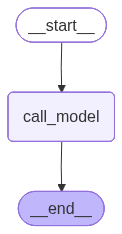

In [8]:
graph

In [9]:
config={"configurable":{"thread_id":"chat-1"}}

result = graph.invoke(
    {"messages": [{"role": "user", "content": "Hi, my name is Nitish."}]},
    config,
)
result['messages'][-1].content




Total Token in msg- 10
Hi, my name is Nitish.


"Hello Nitish, it's nice to meet you. Is there something I can help you with or would you like to chat?"

In [10]:
result=graph.invoke({
    "messages":[HumanMessage(content="what is deep learning?")],

},config=config)

Total Token in msg- 51
Hi, my name is Nitish.
Hello Nitish, it's nice to meet you. Is there something I can help you with or would you like to chat?
what is deep learning?


In [11]:
result['messages'][-1].content


'Deep learning is a subset of machine learning that involves the use of artificial neural networks (ANNs) with multiple layers to analyze and interpret data. These neural networks are inspired by the structure and function of the human brain, with each layer processing the input data in a hierarchical manner.\n\nIn traditional machine learning, algorithms are trained on a dataset to learn a mapping between inputs and outputs. However, deep learning models can learn complex patterns and relationships in data by using multiple layers of non-linear transformations. This allows them to capture subtle features and nuances in the data that may not be apparent to humans.\n\nSome key characteristics of deep learning include:\n\n1. **Multi-layered architecture**: Deep learning models consist of multiple layers of interconnected nodes or "neurons," which process the input data in a hierarchical manner.\n2. **Non-linear transformations**: Each layer applies a non-linear transformation to the inpu

In [12]:
result=graph.invoke({
    "messages":[HumanMessage(content="what is short term memory?")],

},config=config)
result['messages'][-1].content

Total Token in msg- 11
what is short term memory?


'Short-term memory (STM) is a cognitive system that temporarily holds and manipulates information for a short period of time, typically ranging from a few seconds to a minute. It is a limited-capacity memory system that can hold a small amount of information, usually 7 ± 2 chunks of information, as proposed by George Miller in 1956.\n\nShort-term memory is responsible for:\n\n1. **Holding information temporarily**: STM holds information that is currently being processed or attended to, such as phone numbers, passwords, or instructions.\n2. **Manipulating information**: STM allows us to manipulate and transform information, such as repeating a phone number or recalling a sequence of numbers.\n3. **Transferring information to long-term memory**: STM helps to transfer information from short-term memory to long-term memory, where it can be stored for a longer period.\n\nCharacteristics of short-term memory:\n\n1. **Limited capacity**: STM can hold a small amount of information, typically 7

In [13]:
result=graph.invoke({
    "messages":[HumanMessage(content="what is long term memory?")],

},config=config)
result['messages'][-1].content

Total Token in msg- 11
what is long term memory?


'Long-term memory is a type of memory that allows us to store and retain information over an extended period of time, often for years or even a lifetime. It is a fundamental component of human memory and plays a crucial role in our ability to learn, remember, and recall past experiences, events, and knowledge.\n\nCharacteristics of long-term memory:\n\n1. **Duration**: Long-term memory can last from days to years or even a lifetime.\n2. **Capacity**: Long-term memory has a vast capacity to store information, allowing us to retain a vast amount of knowledge and experiences.\n3. **Retrieval**: Information stored in long-term memory can be retrieved through various cues, such as visual, auditory, or emotional associations.\n4. **Consolidation**: Long-term memory involves the process of consolidating information from short-term memory into a more stable and permanent form.\n\nTypes of long-term memory:\n\n1. **Episodic memory**: This type of long-term memory involves the recall of specific

In [14]:
result=graph.invoke({
    "messages":[HumanMessage(content="what is langgraph?")],

},config=config)
result['messages'][-1].content

Total Token in msg- 9
what is langgraph?


'I couldn\'t find any information on "langgraph." It\'s possible that it\'s a very new or niche topic, or it could be a misspelling or incorrect term.\n\nHowever, I can suggest some alternatives that might be related to what you\'re looking for:\n\n1. Language graph: This is a mathematical representation of a language, often used in natural language processing (NLP) and linguistics. It can be a graph where nodes represent words or concepts, and edges represent relationships between them.\n2. Graph-based language models: These are a type of language model that use graph structures to represent language. They can be used for tasks such as language generation, machine translation, and text classification.\n3. Langraphy: This is a term used in linguistics to describe the study of language as a graph. It involves analyzing the structure and relationships between words and concepts in a language.\n\nIf you could provide more context or information about what you\'re looking for, I\'d be happ

In [15]:
for item in graph.get_state({"configurable": {"thread_id": "chat-1"}}).values['messages']:
    print(item.content)
    print('-'*120)

Hi, my name is Nitish.
------------------------------------------------------------------------------------------------------------------------
Hello Nitish, it's nice to meet you. Is there something I can help you with or would you like to chat?
------------------------------------------------------------------------------------------------------------------------
what is deep learning?
------------------------------------------------------------------------------------------------------------------------
Deep learning is a subset of machine learning that involves the use of artificial neural networks (ANNs) with multiple layers to analyze and interpret data. These neural networks are inspired by the structure and function of the human brain, with each layer processing the input data in a hierarchical manner.

In traditional machine learning, algorithms are trained on a dataset to learn a mapping between inputs and outputs. However, deep learning models can learn complex patterns and 